In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from lxml import etree

In [2]:
CSV_PATH       = "/content/dataset_kb1.csv"
MODEL_PATH     = "/content/veeps_spatio_temporal.json"
NET_XML_PATH   = "/content/osm.net.xml"
PREDICT_WINDOW = 60
SPEED_LIMIT    = 14.0
ROLLING_W      = 300
FEATURES       = ['vehicle_count', 'fdr_mean',
                  'FDR_in', 'FDR_out', 'FDR_med', 'FDR_std']

In [3]:
df = pd.read_csv(CSV_PATH)
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Số lane: {df['lane_id'].nunique()}")
print(f"Timestep range: {df['timestep'].min()} → {df['timestep'].max()}")

df['SPI'] = (df['v_mean'] / SPEED_LIMIT).clip(0, 1)
df.head()

Shape: (7874696, 5)
Columns: ['timestep', 'lane_id', 'vehicle_count', 'v_mean', 'fdr_mean']
Số lane: 1465
Timestep range: 4 → 10799


,timestep,lane_id,vehicle_count,v_mean,fdr_mean,SPI
0,4,456678637#0_0,2,4.020,0.613,0.287143
1,5,456678637#0_0,2,5.365,1.035,0.383214
2,6,456678637#0_0,2,6.915,1.548,0.493929
3,7,456678637#0_0,2,8.210,2.087,0.586429
4,8,456678637#0_0,2,8.905,2.582,0.636071


In [4]:
df = df.sort_values(['lane_id', 'timestep']).reset_index(drop=True)

df['FDR_med'] = df.groupby('lane_id')['fdr_mean'].transform(
    lambda x: x.rolling(ROLLING_W, min_periods=1).median()
)
df['FDR_std'] = df.groupby('lane_id')['fdr_mean'].transform(
    lambda x: x.rolling(ROLLING_W, min_periods=1).std().fillna(0)
)

print("FDR_med sample:")
print(df[['timestep','lane_id','fdr_mean','FDR_med','FDR_std']].head(10))

FDR_med sample:
   timestep        lane_id  fdr_mean  FDR_med   FDR_std
0        64  -1011477960_0     2.372   2.3720  0.000000
1        65  -1011477960_0     2.353   2.3625  0.013435
2        66  -1011477960_0     2.362   2.3620  0.009504
3        67  -1011477960_0     2.358   2.3600  0.008057
4       123  -1011477960_0     3.606   2.3620  0.556713
5       124  -1011477960_0     3.629   2.3670  0.648795
6       128  -1011477960_0     3.503   2.3720  0.652269
7       129  -1011477960_0     3.547   2.9375  0.647874
8       209  -1011477960_0     3.542   3.5030  0.635692
9       210  -1011477960_0     3.628   3.5225  0.628441


In [5]:
def build_adjacency(net_xml_path):
    tree = etree.parse(net_xml_path)
    incoming, outgoing = {}, {}
    for conn in tree.findall('.//connection'):
        src = conn.get('from')
        dst = conn.get('to')
        if src and dst:
            outgoing.setdefault(src, []).append(dst)
            incoming.setdefault(dst, []).append(src)
    return incoming, outgoing

try:
    incoming_map, outgoing_map = build_adjacency(NET_XML_PATH)
    print(f"Loaded adjacency — {len(incoming_map)} edges có incoming")
    use_adj = True
except Exception as e:
    print(f"Không load được osm.net.xml: {e}")
    print("→ Fallback: dùng global FDR mean")
    use_adj = False

Loaded adjacency — 1084 edges có incoming


In [6]:
# Pre-compute FDR mean theo từng (timestep, lane_id) để tăng tốc
fdr_pivot  = df.pivot_table(index='timestep', columns='lane_id',
                             values='fdr_mean', aggfunc='mean')
global_fdr = df.groupby('timestep')['fdr_mean'].mean()

def get_neighbor_fdr(lane, timestep, neighbor_map):
    neighbors = neighbor_map.get(lane, [])
    vals = [fdr_pivot.at[timestep, n]
            for n in neighbors
            if n in fdr_pivot.columns and timestep in fdr_pivot.index]
    vals = [v for v in vals if not np.isnan(v)]
    return np.mean(vals) if vals else global_fdr.get(timestep, np.nan)

if use_adj:
    print("Đang tính FDR_in/FDR_out...")
    df['FDR_in'] = df.apply(
        lambda r: get_neighbor_fdr(r['lane_id'], r['timestep'], incoming_map),
        axis=1
    )
    df['FDR_out'] = df.apply(
        lambda r: get_neighbor_fdr(r['lane_id'], r['timestep'], outgoing_map),
        axis=1
    )
    print("Xong!")
else:
    df['FDR_in']  = df['timestep'].map(global_fdr)
    df['FDR_out'] = df['timestep'].map(global_fdr)

df[['lane_id','timestep','FDR_in','FDR_out']].head()

Đang tính FDR_in/FDR_out...
Xong!


,lane_id,timestep,FDR_in,FDR_out
0,-1011477960_0,64,3.705917,3.705917
1,-1011477960_0,65,3.653636,3.653636
2,-1011477960_0,66,3.519182,3.519182
3,-1011477960_0,67,3.419148,3.419148
4,-1011477960_0,123,2.850525,2.850525


In [7]:
# Target: SPI tại t + PREDICT_WINDOW
df['SPI_future'] = df.groupby('lane_id')['SPI'].transform(
    lambda x: x.shift(-PREDICT_WINDOW)
)

df_model = df.dropna(subset=FEATURES + ['SPI_future']).copy()
print(f"Rows hợp lệ để predict: {len(df_model)}")

# Load model và predict
model = xgb.XGBRegressor()
model.load_model(MODEL_PATH)

df_model['SPI_predicted'] = model.predict(df_model[FEATURES]).clip(0, 1)
print("Predict xong!")
df_model[['timestep','lane_id','SPI_future','SPI_predicted']].head()

Rows hợp lệ để predict: 7792408
Predict xong!


,timestep,lane_id,SPI_future,SPI_predicted
0,64,-1011477960_0,0.983571,0.716926
1,65,-1011477960_0,0.965357,0.831361
2,66,-1011477960_0,0.829643,0.822069
3,67,-1011477960_0,0.861429,0.828780
4,123,-1011477960_0,0.880000,0.646847


In [8]:
network_avg = df_model.groupby('timestep').agg(
    SPI_actual    = ('SPI_future',    'mean'),
    SPI_predicted = ('SPI_predicted', 'mean'),
    FDR_med_avg   = ('FDR_med',       'mean'),
).reset_index()

# Metrics
mae  = np.mean(np.abs(network_avg['SPI_actual'] - network_avg['SPI_predicted']))
rmse = np.sqrt(np.mean((network_avg['SPI_actual'] - network_avg['SPI_predicted'])**2))
ss_res = np.sum((network_avg['SPI_actual'] - network_avg['SPI_predicted'])**2)
ss_tot = np.sum((network_avg['SPI_actual'] - network_avg['SPI_actual'].mean())**2)
r2 = 1 - ss_res / ss_tot

print(f"R²   = {r2:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"RMSE = {rmse:.4f}")

R²   = 0.9821
MAE  = 0.0171
RMSE = 0.0257


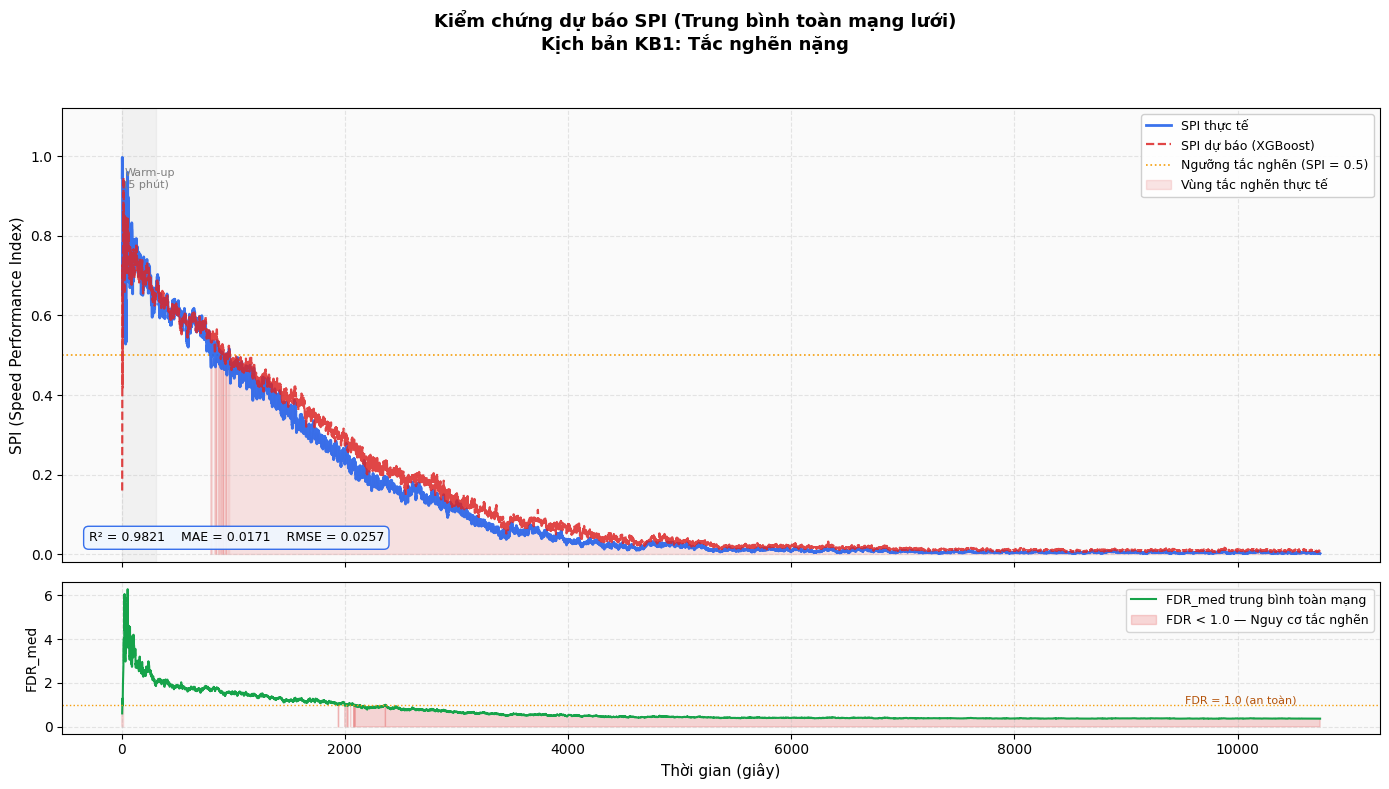

Đã lưu: spi_validation.png


In [9]:
t = network_avg['timestep'].values
warmup_end = t[0] + ROLLING_W

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 8),
    gridspec_kw={'height_ratios': [3, 1]},
    sharex=True
)
fig.suptitle(
    'Kiểm chứng dự báo SPI (Trung bình toàn mạng lưới)\n'
    'Kịch bản KB1: Tắc nghẽn nặng',
    fontsize=13, fontweight='bold'
)

# ── Subplot 1: SPI actual vs predicted ───────────────────────
ax1.plot(t, network_avg['SPI_actual'],
         color='#2563EB', lw=2.0, label='SPI thực tế', alpha=0.9, zorder=3)
ax1.plot(t, network_avg['SPI_predicted'],
         color='#DC2626', lw=1.6, ls='--',
         label='SPI dự báo (XGBoost)', alpha=0.85, zorder=4)

ax1.axhline(0.5, color='#F59E0B', lw=1.2, ls=':',
            label='Ngưỡng tắc nghẽn (SPI = 0.5)', zorder=2)
ax1.fill_between(t, 0, network_avg['SPI_actual'],
                 where=(network_avg['SPI_actual'] < 0.5),
                 alpha=0.12, color='#DC2626', label='Vùng tắc nghẽn thực tế')

ax1.axvspan(t[0], warmup_end, alpha=0.07, color='gray')
ax1.text(t[0] + 20, 0.97, 'Warm-up\n(5 phút)',
         fontsize=8, color='gray', va='top')

ax1.text(0.02, 0.04,
         f'R² = {r2:.4f}    MAE = {mae:.4f}    RMSE = {rmse:.4f}',
         transform=ax1.transAxes, fontsize=9, va='bottom',
         bbox=dict(boxstyle='round,pad=0.4', fc='#EFF6FF',
                   ec='#2563EB', alpha=0.92))

ax1.set_ylabel('SPI (Speed Performance Index)', fontsize=11)
ax1.set_ylim(-0.02, 1.12)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.92)
ax1.grid(True, alpha=0.3, ls='--')
ax1.set_facecolor('#FAFAFA')

# ── Subplot 2: FDR_med (leading indicator) ───────────────────
ax2.plot(t, network_avg['FDR_med_avg'],
         color='#16A34A', lw=1.5, label='FDR_med trung bình toàn mạng')
ax2.axhline(1.0, color='#F59E0B', lw=1.0, ls=':')
ax2.fill_between(t, 0, network_avg['FDR_med_avg'],
                 where=(network_avg['FDR_med_avg'] < 1.0),
                 alpha=0.18, color='#DC2626',
                 label='FDR < 1.0 — Nguy cơ tắc nghẽn')
ax2.text(t[-1] * 0.98, 1.02, 'FDR = 1.0 (an toàn)',
         ha='right', fontsize=8, color='#B45309')

ax2.set_ylabel('FDR_med', fontsize=10)
ax2.set_xlabel('Thời gian (giây)', fontsize=11)
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(True, alpha=0.3, ls='--')
ax2.set_facecolor('#FAFAFA')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('spi_validation.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print("Đã lưu: spi_validation.png")